Columns used for clustering: ['Income', 'Area', 'Employed', 'Education', 'Home_Owner', 'Gender', 'Balance', 'Age', 'Colour']


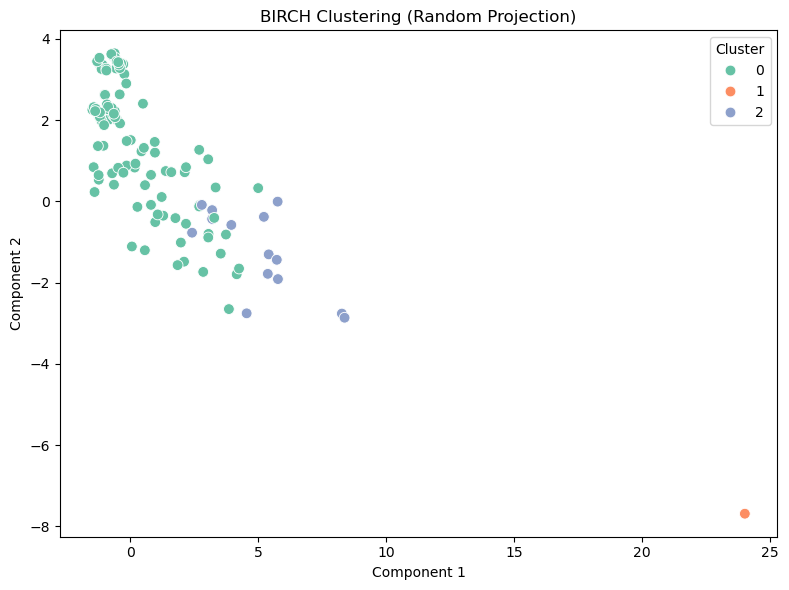

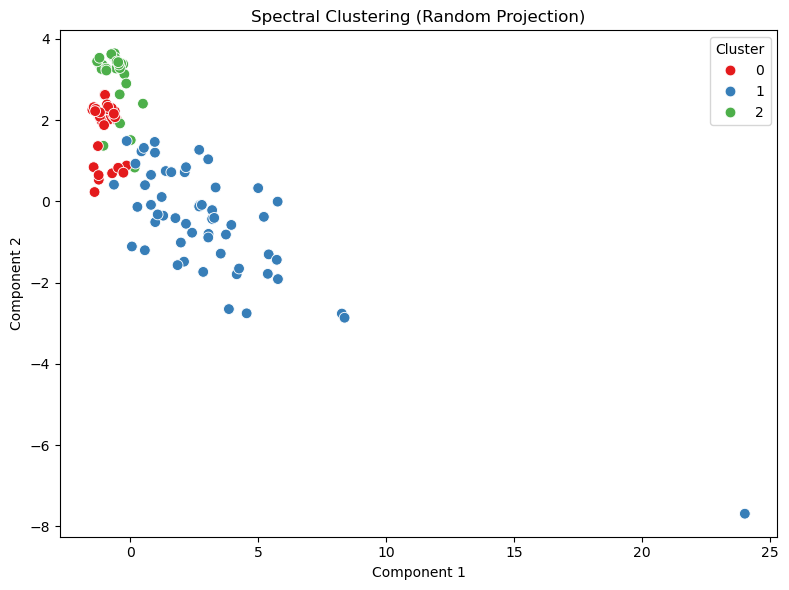


Adjusted Mutual Info Score (BIRCH vs Fraud): 0.100
Adjusted Mutual Info Score (Spectral vs Fraud): 0.659
Silhouette Score (BIRCH): 0.444
Silhouette Score (Spectral Clustering): 0.184


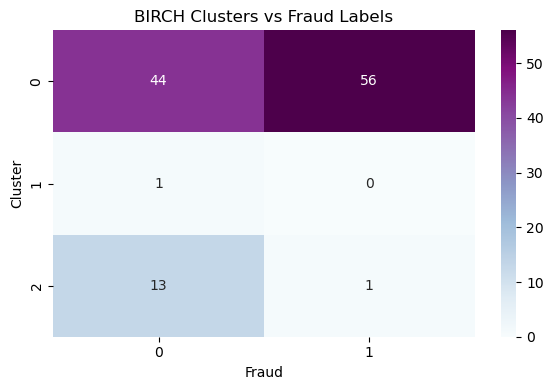

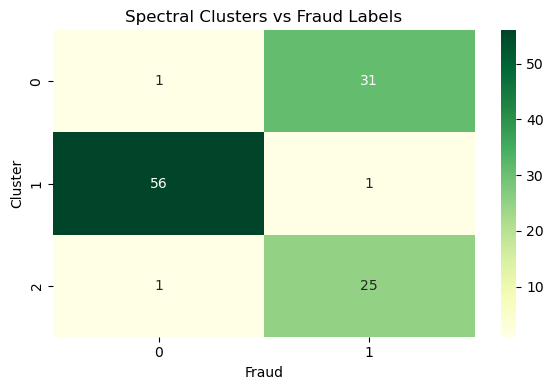

In [6]:
#Task 2 – Unsupervised Learning 

#I'm disabling multi-threading to avoid system overload during clustering
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

#I'm importing the core libraries needed for clustering, data manipulation, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I'm bringing in clustering algorithms and preprocessing tools from sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import Birch, SpectralClustering
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

#I will load the dataset which I cleaned and encoded in Task 1
df = pd.read_csv("cleaned_dataset.csv")

#I save the Fraud column so I can compare my clusters with actual labels later
true_labels = df['Fraud'].copy()

#Since this is unsupervised learning, I remove the Fraud column from the dataset
data_features = df.drop(columns=['Fraud'])

#I double-check that all columns are numeric (important for clustering)
print("Columns used for clustering:", list(data_features.columns))

#I scale the data using RobustScaler which is less sensitive to outliers
scaler = RobustScaler()
scaled_data = scaler.fit_transform(data_features)

# I reduce the data to 2D using Gaussian Random Projection so that I can plot clusters
projection = GaussianRandomProjection(n_components=2, random_state=42)
reduced_data = projection.fit_transform(scaled_data)

# ========== CLUSTERING ==========

# I use the BIRCH clustering algorithm which is fast and good with noise
birch_model = Birch(n_clusters=3)
birch_labels = birch_model.fit_predict(scaled_data)

# I also use Spectral Clustering which works well when the clusters have complex shapes
spectral_model = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
spectral_labels = spectral_model.fit_predict(scaled_data)

# ========== VISUALISING CLUSTERS ==========

#I will plot the clusters formed by BIRCH on the 2D reduced data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=birch_labels, palette='Set2', s=60)
plt.title("BIRCH Clustering (Random Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

#Now I will do the same for Spectral Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=spectral_labels, palette='Set1', s=60)
plt.title("Spectral Clustering (Random Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

#EVALUATING CLUSTERS 

#I calculate Adjusted Mutual Info Score to compare the clustering results with real fraud labels
ami_birch = adjusted_mutual_info_score(true_labels, birch_labels)
ami_spectral = adjusted_mutual_info_score(true_labels, spectral_labels)

print(f"\nAdjusted Mutual Info Score (BIRCH vs Fraud): {ami_birch:.3f}")
print(f"Adjusted Mutual Info Score (Spectral vs Fraud): {ami_spectral:.3f}")

#I also calculate the Silhouette Score to see how tight and separated the clusters are
sil_birch = silhouette_score(scaled_data, birch_labels)
sil_spectral = silhouette_score(scaled_data, spectral_labels)

print(f"Silhouette Score (BIRCH): {sil_birch:.3f}")
print(f"Silhouette Score (Spectral Clustering): {sil_spectral:.3f}")

#HEATMAP COMPARISON 

#I will add the cluster labels back into the dataframe to compare with Fraud
df['BIRCH_Cluster'] = birch_labels
df['Spectral_Cluster'] = spectral_labels
df['Fraud'] = true_labels  # making sure it's available again for cross-tab

#I create a table comparing BIRCH clusters with actual fraud labels
birch_ct = pd.crosstab(df['BIRCH_Cluster'], df['Fraud'])

#And I do the same for Spectral Clustering
spectral_ct = pd.crosstab(df['Spectral_Cluster'], df['Fraud'])

#I will use heatmaps to show how BIRCH clusters relate to fraud
plt.figure(figsize=(6, 4))
sns.heatmap(birch_ct, annot=True, cmap='BuPu', fmt='d')
plt.title("BIRCH Clusters vs Fraud Labels")
plt.ylabel("Cluster")
plt.xlabel("Fraud")
plt.tight_layout()
plt.show()

#I now plot the heatmap for Spectral Clustering
plt.figure(figsize=(6, 4))
sns.heatmap(spectral_ct, annot=True, cmap='YlGn', fmt='d')
plt.title("Spectral Clusters vs Fraud Labels")
plt.ylabel("Cluster")
plt.xlabel("Fraud")
plt.tight_layout()
plt.show()
